In [18]:
from typing import Annotated
from typing import TypedDict

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages
from pydantic import BaseModel, Field


load_dotenv()


True

## Building a Subgraph


In [19]:
# State
class RecommendationState(TypedDict):
    questionnaire: str
    recommendation: str
    confidence_score: float
    attempts: int

In [20]:
class RecommendationOutput(BaseModel):
    recommendation: str = Field(description="The recommendation for the user")
    confidence_score: float = Field(description="The confidence score for the recommendation")

In [21]:
llm = ChatGroq(model="qwen/qwen3-32b", temperature=0.9, reasoning_format="hidden")
subgraph_structured = llm.with_structured_output(RecommendationOutput)

In [22]:
def recommendation_node(state: RecommendationState) -> RecommendationState:
    attempts = state.get("attempts", 0)  # private to the subgraph; 0 on the first pass
    prompt = f"""Write a short (**MAX: 150 words**) recommendation for this person that reads like a thoughtful colleague wrote it, not a corporate or AI-generated blurb. Also give a confidence score (0-1) for how well the responses support it.

Ground every claim in concrete details from the responses, cite a specific example or two, and keep any mixed signals intact - don't make them sound flawless. Vary the sentence rhythm; a little informality is fine. Avoid buzzwords and exaggerated praise.

Aim for 2-3 tight paragraphs: who they are and how they work, their clearest strength with an example, and where they'd fit best. Mention a growth area only if the responses actually support one. Scale length to the input - brief responses get a brief recommendation.

DONT FORGET TO PERSONALIZE THE RECOMMENDATION WITH THE NAME ANKIT AND OTHER DETAILS FROM THE QUESTIONNAIRE.

Questionnaire responses:
{state["questionnaire"]}"""
    response = subgraph_structured.invoke(prompt)
    return {
        "recommendation": response.recommendation,
        "confidence_score": response.confidence_score,
        "attempts": attempts + 1,  # return it so the reducer persists it across the loop
    }


In [23]:
def check_confidence(state: RecommendationState) -> str:
    if state["confidence_score"] >= 0.7 or state["attempts"] >= 3:
        return "high"
    else:
        return "low"

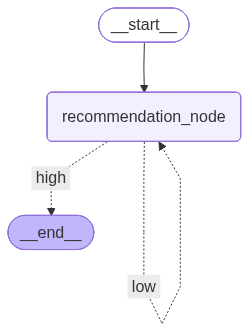

In [24]:
subgraph_checkpointer = InMemorySaver()

recommendation_graph = StateGraph(RecommendationState)

recommendation_graph.add_node("recommendation_node", recommendation_node)

recommendation_graph.add_edge(START, "recommendation_node")
recommendation_graph.add_conditional_edges("recommendation_node", check_confidence, {"high": END, "low": "recommendation_node"})

subgraph_workflow = recommendation_graph.compile(checkpointer=subgraph_checkpointer)

subgraph_workflow

## Building the main graph
### The subgraph will be invoked as a node in the main graph. Notice both the graphs have different state types and checkpointer.


In [25]:
class MainState(TypedDict):
    questionnaire: Annotated[list[str], add_messages]
    recommendation: str
    confidence_score: float

In [26]:
# Questionnaire: each item is a question plus a few quick-pick options.
# The user can type a number to pick an option, or just write their own answer.
QUESTIONS = [
    {
        "question": "What's your relationship to this person?",
        "options": [
            "I managed them",
            "We were peers / teammates",
            "They reported to me",
            "I mentored or taught them",
        ],
    },
    {
        "question": "How long have you worked with them?",
        "options": [
            "Less than 6 months",
            "6 months to 2 years",
            "2 to 5 years",
            "More than 5 years",
        ],
    },
    {
        "question": "What's the one strength that stands out most?",
        "options": [
            "Technical / problem-solving skill",
            "Communication & collaboration",
            "Ownership and reliability",
            "Creativity and fresh thinking",
        ],
    },
    {
        "question": "Describe a specific moment or project where they did great work. What happened?",
        "options": [],  # free text only - this is the part that makes the recommendation real
    },
    {
        "question": "How would you describe their work style?",
        "options": [
            "Independent and self-driven",
            "Highly collaborative",
            "Calm and steady under pressure",
            "Fast-moving and experimental",
        ],
    },
    {
        "question": "Where do you think they'd do their best work?",
        "options": [
            "Small startup / high autonomy",
            "Structured team at a larger company",
            "Research or deep-focus roles",
            "Customer-facing or cross-team roles",
        ],
    },
    {
        "question": "Is there an area where they could grow? (optional - leave blank if none)",
        "options": [],  # free text only
    },
]


In [27]:
def ask_question(q: dict) -> str:
    """Print one question with its options and return the user's answer text."""
    print(f"\n{q['question']}")
    for i, opt in enumerate(q["options"], 1):
        print(f"  {i}. {opt}")
    if q["options"]:
        print("  (enter a number, or type your own answer)")

    raw = input("> ").strip()
    # A number within range picks that option; anything else is free text.
    if raw.isdigit() and 1 <= int(raw) <= len(q["options"]):
        return q["options"][int(raw) - 1]
    return raw


In [28]:
def questionnaire_node(state: MainState) -> MainState:
    answers = []
    for q in QUESTIONS:
        answer = ask_question(q)
        if answer:  # skip blank optional answers
            answers.append(f"Q: {q['question']}\nA: {answer}")
    return {"questionnaire": "\n\n".join(answers)}

In [29]:
def subgraph_invoke(state: MainState) -> MainState:
    result = subgraph_workflow.invoke({"questionnaire": state["questionnaire"]},
                                      config={"configurable": {"thread_id": "subgraph"}})
    return {"recommendation": result["recommendation"], "confidence_score": result["confidence_score"]}

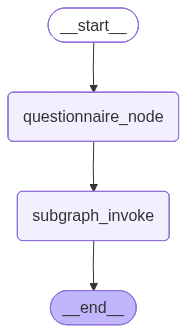

In [30]:
main_graph_checkpointer = InMemorySaver()
main_graph = StateGraph(MainState)

main_graph.add_node("questionnaire_node", questionnaire_node)
main_graph.add_node("subgraph_invoke", subgraph_invoke)

main_graph.add_edge(START, "questionnaire_node")
main_graph.add_edge("questionnaire_node", "subgraph_invoke")
main_graph.add_edge("subgraph_invoke", END)

main_graph = main_graph.compile(checkpointer=main_graph_checkpointer)

main_graph


In [ ]:
generator = main_graph.stream(
    {"questionnaire": []},
    config={"configurable": {"thread_id": "main_graph"}},
    stream_mode="updates",
    subgraphs= True
)

for namespace, update in generator:
    where = namespace[-1].split(":")[0] if namespace else "main"
    print(f"Namespace: {namespace} \n Update: {update}")
    print("\n")

print("\n\n")

final_state = main_graph.get_state(config= {"configurable": {"thread_id": "main_graph"}}).values



print(final_state["recommendation"])
print(final_state["confidence_score"])


What's your relationship to this person?
  1. I managed them
  2. We were peers / teammates
  3. They reported to me
  4. I mentored or taught them
  (enter a number, or type your own answer)


In [ ]:
# result = main_graph.invoke({"questionnaire": []}, config={"configurable": {"thread_id": "main_graph"}})
# print(result["recommendation"])
# print("\n")
# print(result["confidence_score"])

# ------------------------------- LEARNING -------------------------------

## Watching the retry loop with streaming

`.invoke()` only hands back the final state, so the retries are invisible. `.stream()` emits an event after **every step**, and `subgraphs=True` lets those events escape the subgraph boundary so you can watch the loop from the parent.

- **`stream_mode="updates"`** — each event is `{node_name: <the dict that node returned>}`. Ideal for watching `attempts` and `confidence_score` change pass by pass.
- **`subgraphs=True`** — without it, `.stream()` on the main graph treats the subgraph as one opaque step. With it, each event becomes a tuple `(namespace, update)`, where `namespace` is a path tuple naming which subgraph emitted it (`()` = the main graph).

Cell **(A)** streams the subgraph alone — the cleanest view of the loop. Cell **(B)** streams the main graph with `subgraphs=True` so the *same* retries surface through the parent, namespaced.


In [ ]:
# (A) Watch the retry loop directly by streaming the SUBGRAPH itself.
# A deliberately thin questionnaire -> low confidence -> the node loops back and retries.
# stream_mode="updates" yields {node_name: <what that node returned>} after each step,
# so we can watch `attempts` climb and `confidence_score` move on every pass.
# thin_questionnaire = (
#     "Q: What's your relationship to this person?\nA: peer\n\n"
#     "Q: One strength that stands out?\nA: he's fine, hard to say"
# )
#
# for chunk in subgraph_workflow.stream(
#     {"questionnaire": thin_questionnaire},
#     config={"configurable": {"thread_id": "stream-demo-1"}},
#     stream_mode="updates",
# ):
#     update = chunk["recommendation_node"]
#     print(f"attempt {update['attempts']}  |  confidence={update['confidence_score']:.2f}")


In [ ]:
# (B) Same loop, but watched from the MAIN graph.
# By default .stream() treats the subgraph as a black box: you'd see one
# "subgraph_invoke" update and nothing about the retries inside it.
# subgraphs=True makes the nested steps bubble up, each tagged with a
# `namespace` tuple telling you WHICH subgraph emitted it (() == main graph).
# NOTE: this runs the real graph, so questionnaire_node will prompt you to type answers.
# for namespace, update in main_graph.stream(
#     {"questionnaire": []},
#     config={"configurable": {"thread_id": "stream-demo-2"}},
#     stream_mode="updates",
#     subgraphs=True,
# ):
#     where = namespace[-1].split(":")[0] if namespace else "main"
#     for node, payload in update.items():
#         bits = []
#         if "attempts" in payload:
#             bits.append(f"attempt={payload['attempts']}")
#         if "confidence_score" in payload:
#             bits.append(f"conf={payload['confidence_score']:.2f}")
#         print(f"[{where}] {node}  {' '.join(bits)}")
